In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Read DataSet
df = pd.read_csv("creditcard.csv")
print(df.head())
print('\n',df.info())
print(df.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [2]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

### Class 0 >> Class 1
#### it represents high imbalance

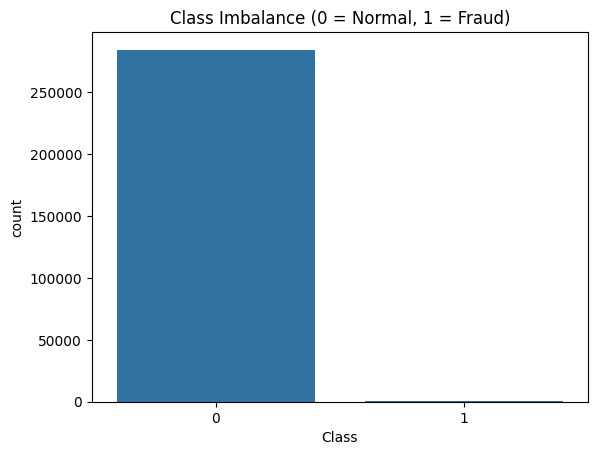

In [3]:
sns.countplot(x='Class',data=df)
plt.title("Class Imbalance (0 = Normal, 1 = Fraud)")
plt.show()

#### Class Imbalance Observation

The dataset is highly imbalanced, with fraudulent transactions representing a very small fraction (~0.17%) of the total data.

This imbalance makes accuracy an unreliable metric, as a model can achieve high accuracy by simply predicting all transactions as non-fraudulent.

Therefore, evaluation metrics such as recall, precision, and ROC-AUC are more appropriate for this problem.

In [4]:
#Data Seperation
X = df.drop("Class",axis=1)
y = df["Class"]


In [5]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42, stratify=y)

print("Train distribution:\n", y_train.value_counts(normalize=True))
print("\nTest disribution:\n", y_test.value_counts(normalize=True))

Train distribution:
 Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

Test disribution:
 Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [9]:
from sklearn.preprocessing import StandardScaler

# Define the columns to scale
cols_to_scale = ['Amount', 'Time']

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(X_train[cols_to_scale].describe())

             Amount          Time
count  2.278450e+05  2.278450e+05
mean  -3.991726e-18  1.708957e-17
std    1.000002e+00  1.000002e+00
min   -3.516894e-01 -1.998073e+00
25%   -3.291944e-01 -8.561495e-01
50%   -2.639429e-01 -2.122647e-01
75%   -4.262209e-02  9.366285e-01
max    1.021170e+02  1.640549e+00


### Feature Scaling

The 'Amount' and 'Time' features were scaled using StandardScaler to normalize their ranges.

Scaling was applied only on the training data and then used to transform the test data to prevent data leakage.

The remaining features (V1–V28) were already normalized using PCA and did not require additional scaling.

In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res,y_train_res = smote.fit_resample(X_train,y_train)

print("Before SMOTE:\n",y_train.value_counts())
print("After SMOTE:\n",y_train_res.value_counts())

Before SMOTE:
 Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE:
 Class
0    227451
1    227451
Name: count, dtype: int64


### Handling Class Imbalance

The dataset is highly imbalanced, so SMOTE (Synthetic Minority Oversampling Technique) was applied to the training data.

SMOTE generates synthetic samples for the minority class (fraud cases), helping the model learn patterns more effectively.

It was applied only to the training set to avoid data leakage and ensure realistic evaluation on the test set.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr_model = LogisticRegression(max_iter=2000)
rf_model = RandomForestClassifier(random_state=42)

lr_model.fit(X_train_res,y_train_res)
rf_model.fit(X_train_res,y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
#Predictions

#Logistic Regression
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

#RandomForest
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

### Model Training

Two models were trained for comparison:

- Logistic Regression: Used as a baseline model
- Random Forest: Used to capture non-linear relationships in the data

Training was performed on the SMOTE-balanced dataset to improve fraud detection capability.

In [13]:
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score

#Logistic Reggression
print("==Logistic Regression==")
print(confusion_matrix(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))
print("ROC-AUC:",roc_auc_score(y_test,y_pred_lr))

#Random Forest
print("\n==Random Forest==")
print(confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))
print("ROC-AUC:",roc_auc_score(y_test,y_pred_rf))

==Logistic Regression==
[[55403  1461]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.946337232839112

==Random Forest==
[[56849    15]
 [   16    82]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9182354532978076


### Model Comparison Insights

Logistic Regression achieved high recall but extremely low precision, resulting in a large number of false positives.

Random Forest provided a better balance between precision and recall, making it more suitable for real-world fraud detection where both detecting fraud and minimizing false alarms are important.

Although Logistic Regression detects slightly more fraud cases, its high false positive rate makes it impractical for deployment.

In [14]:
# Threshold Tuning

threshold = 0.3

y_pred_custom = (y_prob_rf > threshold).astype(int)
print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[56833    31]
 [   10    88]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.74      0.90      0.81        98

    accuracy                           1.00     56962
   macro avg       0.87      0.95      0.91     56962
weighted avg       1.00      1.00      1.00     56962



### Threshold Tuning

A custom threshold was applied to adjust the balance between precision and recall.

Lowering the threshold increased fraud detection (recall) at the cost of more false positives.

This allows tuning the model based on business requirements.

c:\Users\jayan\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


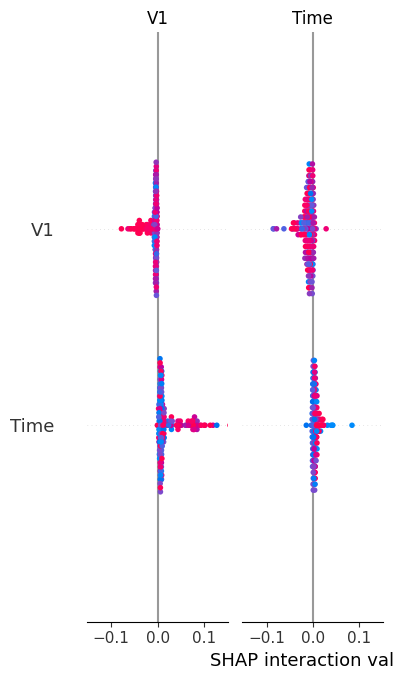

In [15]:
# SHAP
import shap

X_sample = X_test.sample(200,random_state=42)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_sample)
shap.summary_plot(shap_values,X_sample)

### Insights

- Features like `V1` and `Time` significantly influence fraud detection
- Higher feature values tend to increase fraud probability
- The model relies on a combination of multiple features rather than a single dominant factor

This improves transparency and trust in the model.

In [17]:
import joblib

# 1. Save the model
joblib.dump(rf_model, "fraud_model.pkl")

# 2. Save the scaler (this contains the mean/std for BOTH Amount and Time)
joblib.dump(scaler, "scaler.pkl")

# 3. Save the list of column names
model_columns = list(X_train.columns)
joblib.dump(model_columns, "fraud_model_columns.pkl")

print("Model, Scaler, and Columns saved successfully!")

Model, Scaler, and Columns saved successfully!
